In [ ]:
# Erstmal notwendige Bibliotheken laden

import graphviz
import pm4py
from pm4py.objects.petri_net.utils import initial_marking
from pm4py.visualization.transition_system.util.visualize_graphviz import visualize

In [37]:
# Daten reinladen
# Pfad bitte anpassen, falls ihr es bei euch laufen lasst.
dataframe = df = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-08 TYT_event_log V4.xes')

parsing log, completed traces :: 100%|██████████| 3339/3339 [00:04<00:00, 780.60it/s] 


In [ ]:
df.head()

In [31]:
print(df.isna().sum())

concept:name            0
time:timestamp          0
age                  5611
gender               2549
sound_env            2145
case:concept:name       0
dtype: int64


# Mining anwenden und Grafiken ausgeben

In [ ]:
# Abkürzungen

# im = initial_marking
# fm = final_marking
# alpha_m = Alpha Miner
# heuristic_m = Heuristic Miner
# inductive_m = Inductive Miner
# ilp_m = ILP Miner
# dfg_m = DFG Miner
# genetic_m = Genetic Miner
# Alpha Miner

In [38]:
log = df.copy()

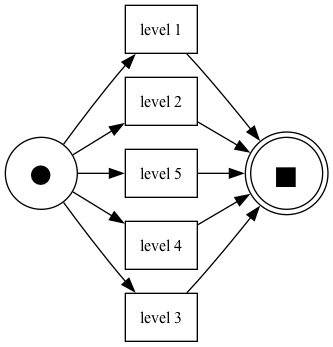

In [39]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner

net_alpha_m, im_alpha_m, fm_alpha_m = alpha_miner.apply(log)
pm4py.view_petri_net(net_alpha_m, im_alpha_m, fm_alpha_m)

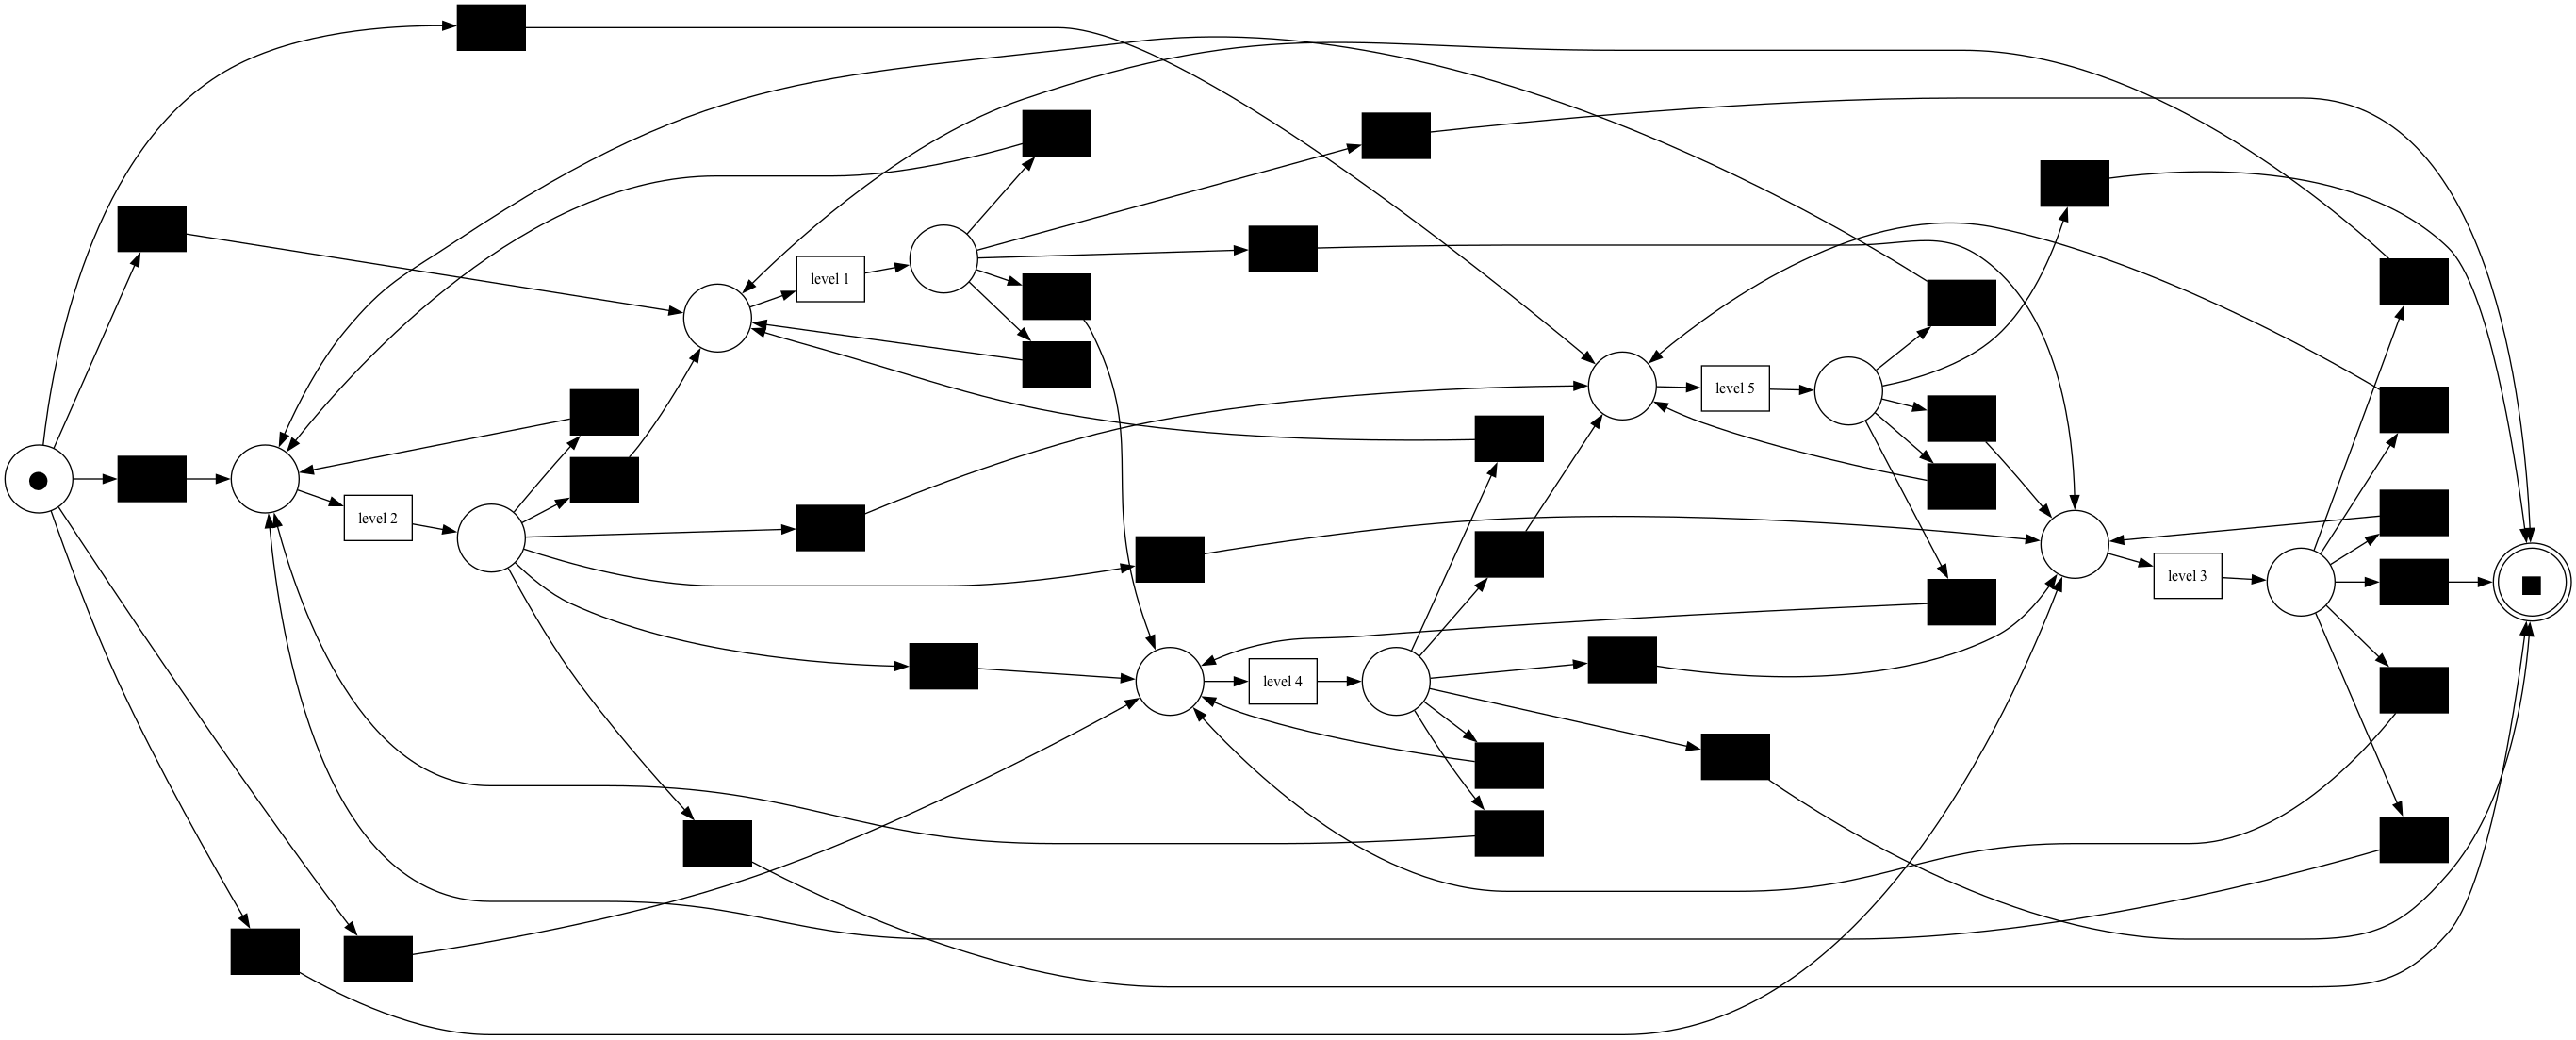

In [40]:
# Heuristic Miner
from pm4py.algo.discovery.heuristics import algorithm as heuristic_miner

net_heuristic_m, im_heuristic_m, fm_heuristic_m = heuristic_miner.apply(log)
pm4py.view_petri_net(net_heuristic_m, im_heuristic_m, fm_heuristic_m)

In [ ]:
# Inductive Miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner

tree = inductive_miner.apply(log)
net_inductive_m, im_inductive_m, fm_inductive_m = pm4py.convert_to_petri_net(tree)
pm4py.view_petri_net(net_inductive_m, im_inductive_m, fm_inductive_m)

In [ ]:
# ILP Miner

# lief 22min und es ging nicht voran

# PuLP NICHT installieren, dann geht der Codeblock nicht mehr!!
'''
from pm4py.algo.discovery.ilp import algorithm as ilp_miner

net_ilp_m, im_ilp_m, fm_ilp_m = ilp_miner.apply(log)
pm4py.view_petri_net(net_ilp_m, im_ilp_m, fm_ilp_m)'''

In [35]:
# DFG (Directly-Follows-Graph) anstelle von Fuzzy Miner als Approximation
# PM4Py hat keinen Fuzzy Miner, höchstens ProM

# DFG (Directly Follows Graph) mit Häufigkeiten/Durchlaufzeiten und unterschiedlicher Pfeildicke
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery

dfg = dfg_discovery.apply(log)

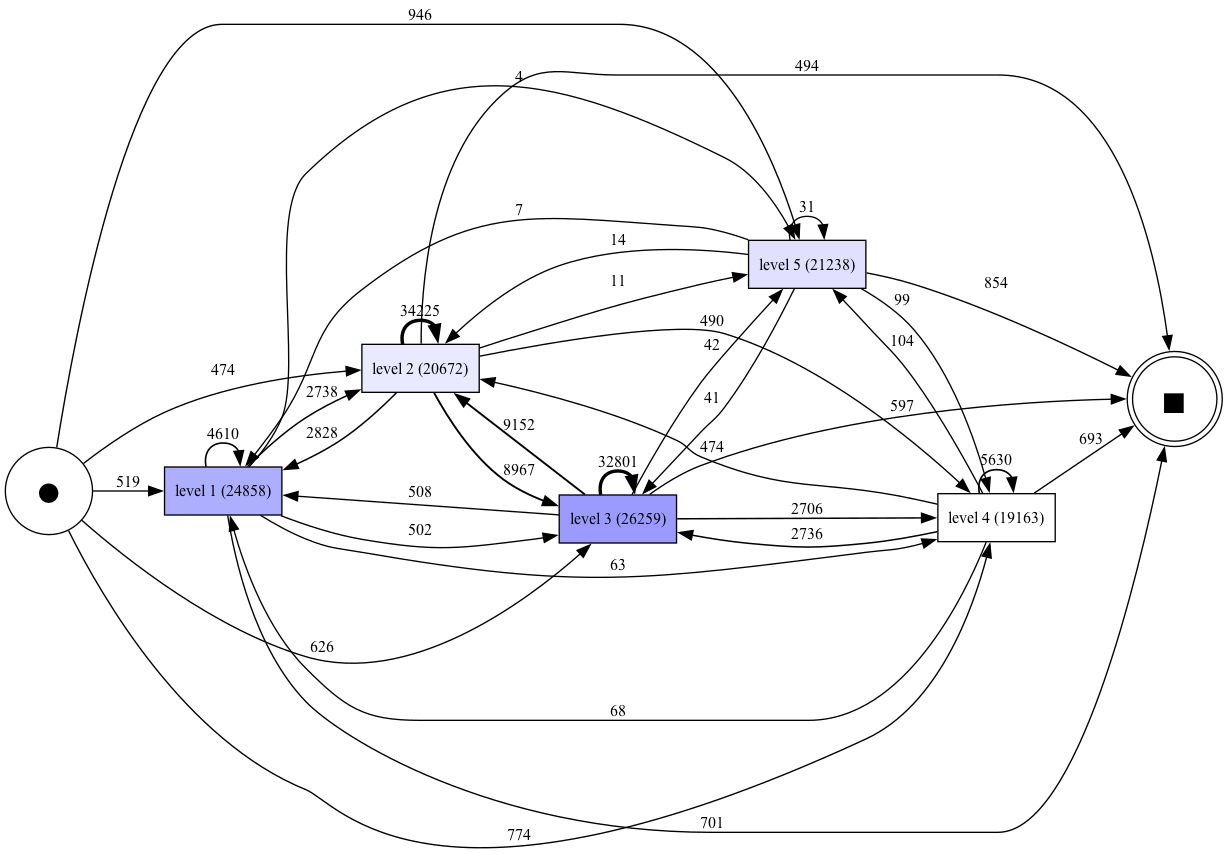

In [41]:
# Visualisierung mit Häufigkeiten
from pm4py.statistics.start_activities.log import get as start_activities
from pm4py.statistics.end_activities.log import get as end_activities

start_acts = start_activities.get_start_activities(log)
end_acts = end_activities.get_end_activities(log)

from pm4py.visualization.dfg import visualizer as dfg_visualization

gviz = dfg_visualization.apply(
    dfg,
    log=log,
    variant=dfg_visualization.Variants.FREQUENCY,
    parameters={
        "start_activities": start_acts,
        "end_activities": end_acts
    }
)

dfg_visualization.view(gviz)

In [ ]:
# Fitness, Precision, Generalisation und Simplicity
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

In [ ]:
# Evaluierung als Definition, um das später leichter zu haben.
# Wählt eigenständig den Token Based Replay oder Alignment für Fitness für den jeweiligen Miner!

def evaluate_model(log, net, im, fm):
    fitness_result = replay_fitness.apply(log, net, im, fm)
    precision = precision_evaluator.apply(log, net, im, fm)
    generalization = generalization_evaluator.apply(log, net, im, fm)
    simplicity = simplicity_evaluator.apply(net)

    fitness_value = fitness_result.get('log_fitness') or fitness_result.get('average_trace_fitness')

    print(f"Fitness: {fitness_result}"),
    print(f"Precision: {precision * 100:.4f}%"),
    print(f"Generalization: {generalization :.4f}"),
    print(f"Simplicity: {simplicity :.4f}")

    # Rückgabe als Dictionary für Tabelle
    return {
        "Fitness": fitness_value,
        "Precision": precision,
        "Generalization": generalization,
        "Simplicity": simplicity
    }

# Dictionary zum Speichern der Ergebnisse
all_results = {}

In [ ]:
# Evaluierung Alpha Miner
print(f'Alpha Miner')
all_results['Alpha'] = evaluate_model(log, net_alpha_m, im_alpha_m, fm_alpha_m)

In [ ]:
# Evaluierung Heuristic Miner
print(f'Heuristic Miner')
all_results['Heuristic'] = evaluate_model(log, net_heuristic_m, im_heuristic_m, fm_heuristic_m)

In [ ]:
# Evaluierung Inductive Miner
print(f'Inductive Miner')
all_results['Inductive'] = evaluate_model(log, net_inductive_m, im_inductive_m, fm_inductive_m)

In [ ]:
# Evaluierung ILP Miner
'''print(f'ILP Miner')
all_results['ILP'] = evaluate_model(log, net_ilp_m, im_ilp_m, fm_ilp_m)'''

In [ ]:
# Evaluierung DFG

# testen, ob sich das dann evaluieren lässt -> ja das klappt. Macht das dann überhaupt Sinn oder weicht das vom eigentlichen Output von oben ab?
# Chattie sagt nämlich, dass die Konvertierung: heuristisch ist, Struktur verzerren kann und Metriken beeinflusst
from pm4py.objects.conversion.dfg import converter as dfg_converter

net_dfg, im_dfg, fm_dfg = dfg_converter.apply(dfg)

print("DFG (converted)")
all_results['DFG (converted)'] = evaluate_model(log, net_dfg, im_dfg, fm_dfg)

In [ ]:
# Evaluierung Genetic Miner
# aktivieren wenn der Genetic Miner auch ausgeführt wird

#print(f'Genetic Miner')
#all_results['Genetic'] = evaluate_model(log, net_genetic_m, im_genetic_m, fm_genetic_m)
# Pandas DataFrames aus Dictionary erstellen

In [ ]:
import pandas as pd
df_comparison = pd.DataFrame.from_dict(all_results, orient='index')

# Formatierung für die Anzeige (% und :.4f)
df_display = df_comparison.copy()
for col in ["Fitness", "Precision"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x * 100:.2f}%")

for col in ["Generalization", "Simplicity"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")

print("Übersicht:")
print(df_display)
# oder display(df_display)